In [1]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_tuner as kt

from google.colab import files

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("Keras Tuner:", kt.__version__)

TensorFlow: 2.20.0
Keras Tuner: 1.4.8


In [3]:
!wget -q -O apple-disease.zip \
"https://www.kaggle.com/api/v1/datasets/download/rm1000/apple-disease-dataset-original"

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [4]:
extract_path = "/content/apple_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile("/content/apple-disease.zip", "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
for root, dirs, files_list in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "  " * level
    print(indent + os.path.basename(root) + "/")

    if level < 2:
        for file in files_list[:5]:
            print(indent + "  " + file)

apple_dataset/
  Original Data/
    test/
      Apple___Cedar_apple_rust/
      Apple___healthy/
      Apple___Apple_scab/
      Apple___Black_rot/
    train/
      Apple Scab/
      Healthy/
      Cedar Apple Rust/
      Black Rot/


In [6]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

class_folders = []

for root, dirs, files_list in os.walk(extract_path):
    image_count = sum(
        file.lower().endswith(image_extensions)
        for file in files_list
    )

    if image_count > 10:
        class_folders.append(root)

print("Possible class folders:")
for folder in class_folders:
    print(folder)

Possible class folders:
/content/apple_dataset/Original Data/test/Apple___Cedar_apple_rust
/content/apple_dataset/Original Data/test/Apple___healthy
/content/apple_dataset/Original Data/test/Apple___Apple_scab
/content/apple_dataset/Original Data/test/Apple___Black_rot
/content/apple_dataset/Original Data/train/Apple Scab
/content/apple_dataset/Original Data/train/Healthy
/content/apple_dataset/Original Data/train/Cedar Apple Rust
/content/apple_dataset/Original Data/train/Black Rot


In [7]:
dataset_dir = None

for root, dirs, files_list in os.walk(extract_path):
    valid_subfolders = []

    for d in dirs:
        folder_path = os.path.join(root, d)

        image_count = 0
        for _, _, fs in os.walk(folder_path):
            image_count += sum(
                f.lower().endswith(image_extensions)
                for f in fs
            )

        if image_count > 10:
            valid_subfolders.append(d)

    if len(valid_subfolders) >= 4:
        dataset_dir = root
        break

print("Dataset directory:")
print(dataset_dir)

Dataset directory:
/content/apple_dataset/Original Data/test


In [8]:
class_names = sorted([
    d for d in os.listdir(dataset_dir)
    if os.path.isdir(os.path.join(dataset_dir, d))
])

print("Classes:")
for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

Classes:
0 : Apple___Apple_scab
1 : Apple___Black_rot
2 : Apple___Cedar_apple_rust
3 : Apple___healthy


In [9]:
class_counts = {}

for class_name in class_names:
    folder = os.path.join(dataset_dir, class_name)

    count = 0

    for root, dirs, files_list in os.walk(folder):
        count += sum(
            file.lower().endswith(image_extensions)
            for file in files_list
        )

    class_counts[class_name] = count

print("Number of images per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Number of images per class:

Apple___Apple_scab: 504
Apple___Black_rot: 497
Apple___Cedar_apple_rust: 440
Apple___healthy: 502


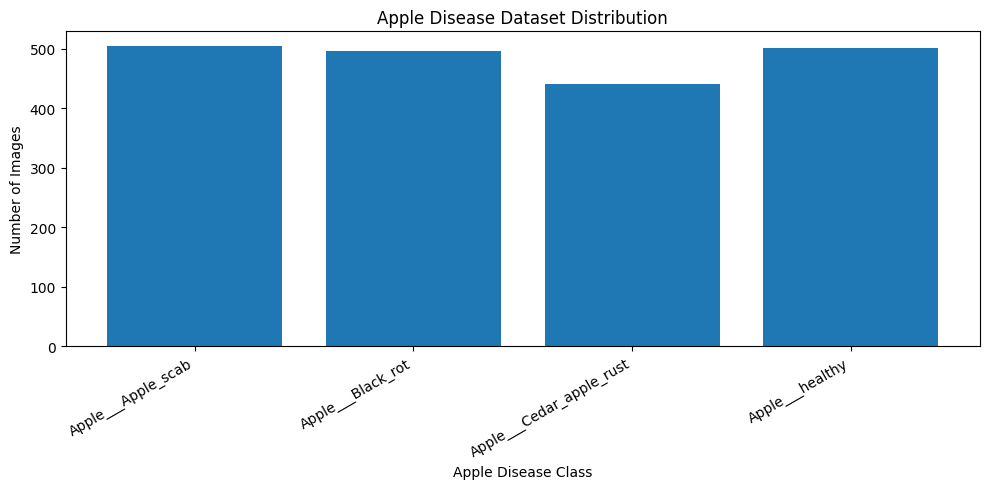

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xticks(rotation=30, ha="right")
plt.xlabel("Apple Disease Class")
plt.ylabel("Number of Images")
plt.title("Apple Disease Dataset Distribution")

plt.tight_layout()
plt.show()

In [11]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 1943 files belonging to 4 classes.
Using 1555 files for training.
Found 1943 files belonging to 4 classes.
Using 388 files for validation.
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']


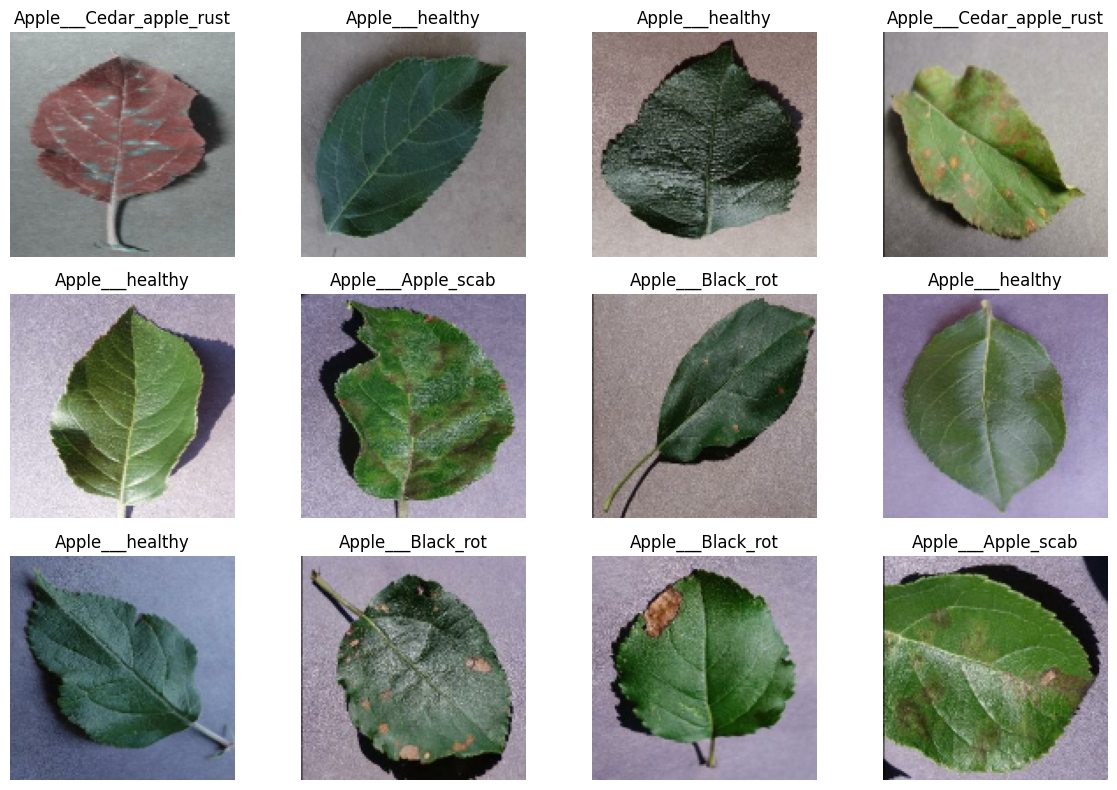

In [12]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15)
])

In [15]:
num_classes = len(class_names)

model = models.Sequential([

    # Input
    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4412 - loss: 1.2409 - val_accuracy: 0.6082 - val_loss: 0.9195
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.6469 - loss: 0.8520 - val_accuracy: 0.7990 - val_loss: 0.5309
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7768 - loss: 0.6083 - val_accuracy: 0.7216 - val_loss: 0.6668
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8013 - loss: 0.5482 - val_accuracy: 0.8582 - val_loss: 0.4146
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8199 - loss: 0.4673 - val_accuracy: 0.7010 - val_loss: 0.9756
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8431 - loss: 0.4045 - val_accuracy: 0.8170 - val_loss: 0.5396
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8392 - loss: 0.4183 - val_accuracy: 0.8067 - val_loss: 0.4627
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8457 - loss: 0.4208 - val_accuracy: 0.7912 - val_loss:

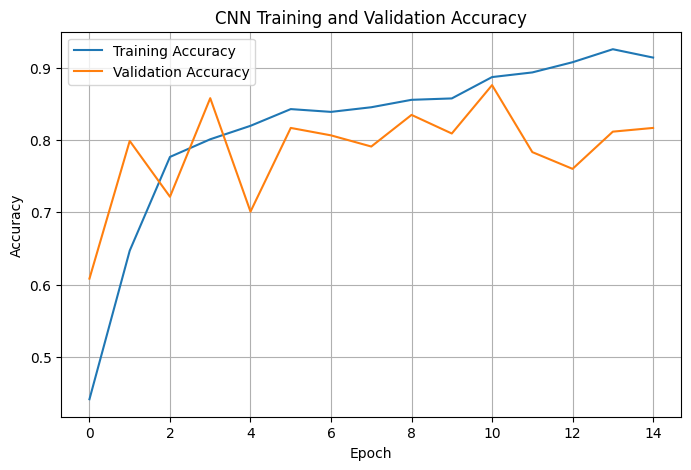

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.grid(True)
plt.show()

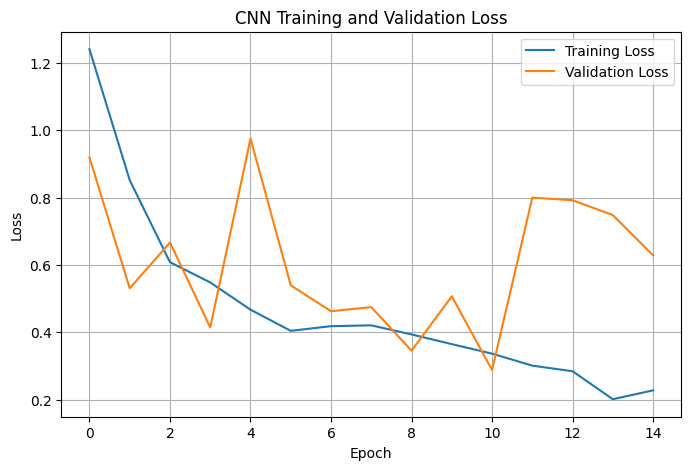

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.grid(True)
plt.show()

In [20]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - accuracy: 0.8170 - loss: 0.6286
Validation Loss: 0.6286184787750244
Validation Accuracy: 0.8170102834701538


In [21]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")

Predictions generated successfully!


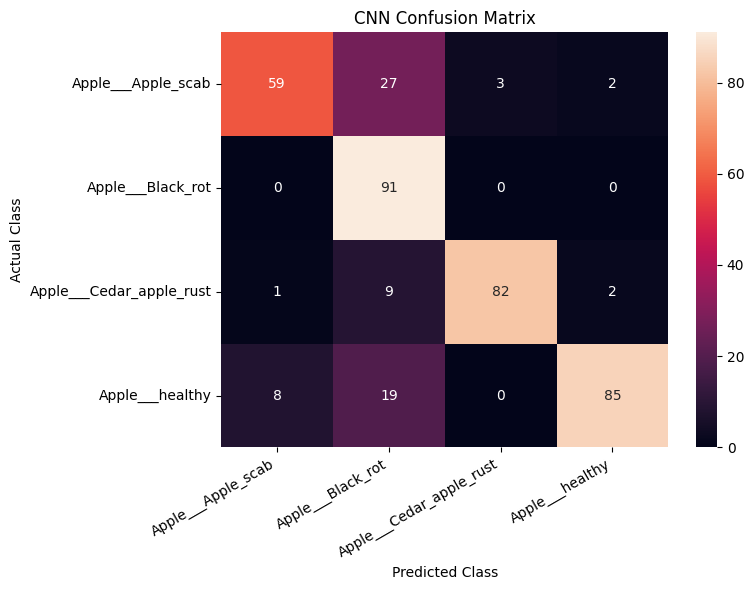

In [22]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Confusion Matrix")

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
model.save("/content/apple_disease_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [24]:
files.download("/content/apple_disease_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
uploaded = files.upload()

Saving J7DMyvZIqmn4XdtRtqT9V6veD80Iv7RVrjbF1V6R-BHzXYUZbaBSftO5PL6LI7XljFQJsQWnUuj0yJcHWuM2k8gsaQ4gSnwdefaHhfMDqM3Vl5IVnTqa5-oKrP5LE3vM5mGmjKLAswOGyjHTD_MRnI8GlQ4yrw2FBHHsKjyRkU1Q9v-voVLgqgvdAxwTVmRS.jpg to J7DMyvZIqmn4XdtRtqT9V6veD80Iv7RVrjbF1V6R-BHzXYUZbaBSftO5PL6LI7XljFQJsQWnUuj0yJcHWuM2k8gsaQ4gSnwdefaHhfMDqM3Vl5IVnTqa5-oKrP5LE3vM5mGmjKLAswOGyjHTD_MRnI8GlQ4yrw2FBHHsKjyRkU1Q9v-voVLgqgvdAxwTVmRS (1).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


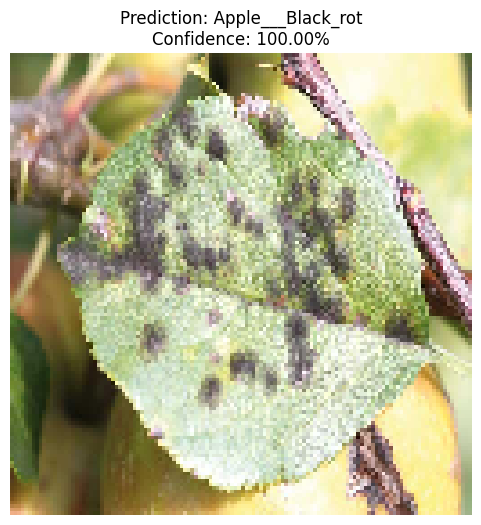

Predicted Disease: Apple___Black_rot
Confidence: 100.00%


In [27]:
from tensorflow.keras.utils import load_img, img_to_array

uploaded_file = list(uploaded.keys())[0]

img = load_img(
    uploaded_file,
    target_size=IMG_SIZE
)

img_array = img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])

predicted_class = class_names[predicted_index]

confidence = predictions[0][predicted_index] * 100

plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

print("Predicted Disease:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

In [28]:
print("Prediction Probabilities:\n")

for class_name, probability in zip(
    class_names,
    predictions[0]
):
    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )

Prediction Probabilities:

Apple___Apple_scab: 0.00%
Apple___Black_rot: 100.00%
Apple___Cedar_apple_rust: 0.00%
Apple___healthy: 0.00%
